## 3. demand forecasting

train a lightgbm model to predict avg_available: the mean bikes at a station in a given hour.

the model uses lag_24h (same hour yesterday), lag_48h (two days ago), and lag_168h (same hour last week) as its most recent state signals — no lag_1h. this means the model is valid for any prediction horizon from now up to 24h ahead, because yesterday's same-hour reading is always available at inference time regardless of how far into the future you're predicting. a rebalancing manager can use this to plan several hours ahead, not just the next hour.

known limitation: training data had rebalancing-distorted hours removed. so the model predicts organic demand. during active rebalancing, predictions will diverge from observations. this is expected and can be used as a rebalancing trigger signal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import pathlib
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

FEATURES_PATH = pathlib.Path('../data/features.parquet')

if not FEATURES_PATH.exists():
    raise FileNotFoundError(f'{FEATURES_PATH} not found — run 02_features.ipynb first')

## 1. load features

In [2]:
df = pd.read_parquet(FEATURES_PATH)
df['hour'] = pd.to_datetime(df['hour'])

print(f'shape:      {df.shape}')
print(f'stations:   {df["station_uid"].nunique():,}')
print(f'date range: {df["hour"].min()} to {df["hour"].max()}')

before = len(df)
df = df.dropna(subset=['lag_24h', 'lag_168h'])
print(f'dropped {before - len(df):,} rows missing lags, {len(df):,} remain')

print('\ntarget distribution:')
print(df['avg_available'].describe().round(2))

# load station names for display in analysis cells
_names_path = FEATURES_PATH.parent / 'station_names.parquet'
if _names_path.exists():
    station_names = pd.read_parquet(_names_path)
    print(f'\nstation names loaded: {len(station_names):,} stations')
else:
    station_names = pd.DataFrame(columns=['station_uid', 'name'])
    print('\nstation_names.parquet not found — re-run 02_features.ipynb to generate it')

df.head(3)

shape:      (1756389, 47)
stations:   760
date range: 2026-03-01 00:00:00 to 2026-08-30 01:00:00


dropped 225,185 rows missing lags, 1,531,204 remain

target distribution:
count    1531204.00
mean           1.84
std            2.40
min            0.00
25%            0.00
50%            1.00
75%            3.00
max           42.00
Name: avg_available, dtype: float64



station names loaded: 1,513 stations


,station_uid,hour,avg_available,lat,lng,bike_racks,district,dist_metro_m,n_metro_500m,dist_tram_m,n_tram_300m,dist_cafe_m,n_cafe_300m,dist_park_m,n_park_500m,dist_office_m,n_office_500m,is_in_park,elevation_m,hour_of_day,dow,month,is_weekend,is_holiday,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,temperature,precipitation,windspeed,weathercode,snowfall,shortwave_radiation,tsun,lag_1h,lag_24h,lag_48h,lag_168h,lag_24h_ratio,hours_since_reb,reb_per_week,avail_std,zero_rate_3d,near_zero_rate_3d
135,27581946,2026-03-07 23:00:00,0.0,50.06821,14.45876,10,10,1201.9,0,23.7,7,47.8,32,55.0,6,150.4,5,0,215.0,23,5,3,1,0,-0.258819,0.965926,-0.974928,-0.222521,1.0,6.123234e-17,6.8,0.0,5.3,0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,NaN,0.0,1.07454,0.763889,0.763889
136,27581946,2026-03-08 00:00:00,0.0,50.06821,14.45876,10,10,1201.9,0,23.7,7,47.8,32,55.0,6,150.4,5,0,215.0,0,6,3,1,0,0.000000,1.000000,-0.781831,0.623490,1.0,6.123234e-17,5.3,0.0,4.5,0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,NaN,0.0,1.07454,0.763889,0.763889
137,27581946,2026-03-08 03:00:00,0.0,50.06821,14.45876,10,10,1201.9,0,23.7,7,47.8,32,55.0,6,150.4,5,0,215.0,3,6,3,1,0,0.707107,0.707107,-0.781831,0.623490,1.0,6.123234e-17,3.0,0.0,4.0,1,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,NaN,0.0,1.07454,0.763889,0.763889


## 2. walk-forward cross-validation

instead of a single train/test split, we evaluate across multiple time windows. each fold expands the training set and tests on the next unseen period. this avoids the seasonality problem where a single split can accidentally land on a very easy or very hard period.

the naive baseline (lag_24h) is computed in each fold too, so we see the improvement over "just predict yesterday" across different seasons, not just one arbitrary test window.

MIN_TRAIN_WEEKS and TEST_FOLD_WEEKS control the fold logic. with more data (e.g. after syncing from supabase), the same code creates more folds automatically — nothing needs to change.

In [ ]:
GEO_COLS = [c for c in df.columns if c.startswith(('dist_', 'n_metro', 'n_tram', 'n_cafe', 'n_park', 'n_office', 'elevation', 'is_in_'))]

FEATURE_COLS = [
    'lat', 'lng', 'bike_racks', 'district',
    *GEO_COLS,
    'hour_of_day', 'dow', 'month', 'is_weekend', 'is_holiday',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'temperature', 'precipitation', 'windspeed', 'weathercode', 'snowfall',
    'shortwave_radiation', 'tsun',
    'lag_24h', 'lag_48h', 'lag_168h',
    'lag_24h_ratio',
    'hours_since_reb',
    'reb_per_week',
    'avail_std',
    'zero_rate_3d',
    'near_zero_rate_3d',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET = 'avg_available'

print(f'features: {len(FEATURE_COLS)} columns  ({len(GEO_COLS)} geo)')

# ── walk-forward cross-validation ─────────────────────────────────────────────
MIN_TRAIN_WEEKS = 8
TEST_FOLD_WEEKS = 4
# skip folds where the test set is too small to be informative — likely a scraper outage.
# fold 3 (2026-06-27 to 2026-07-25) had only 1,478 test rows due to a scraper outage;
# including it would distort the cv mean (easy period inflates score).
MIN_TEST_ROWS = 10_000

data_start = df['hour'].min()
data_end   = df['hour'].max()

folds = []
test_start = data_start + pd.Timedelta(weeks=MIN_TRAIN_WEEKS)
while test_start + pd.Timedelta(weeks=TEST_FOLD_WEEKS) <= data_end:
    test_end = test_start + pd.Timedelta(weeks=TEST_FOLD_WEEKS)
    folds.append((data_start, test_start, test_end))
    test_start = test_end

total_weeks = (data_end - data_start).days // 7
print(f'data: {total_weeks} weeks  ({data_start.date()} — {data_end.date()})')
print(f'{len(folds)} CV folds (min_train={MIN_TRAIN_WEEKS}w, fold_size={TEST_FOLD_WEEKS}w, min_test_rows={MIN_TEST_ROWS:,})')
for i, (_, ts, te) in enumerate(folds):
    tw = (ts - data_start).days // 7
    print(f'  fold {i+1}: train {data_start.date()}–{ts.date()} ({tw}w)  →  test {ts.date()}–{te.date()}')

cv_records = []

for fold_i, (train_start, test_start, test_end) in enumerate(folds, 1):
    val_start = test_start - pd.Timedelta(weeks=2)

    tr = df[(df['hour'] >= train_start) & (df['hour'] < val_start)]
    va = df[(df['hour'] >= val_start)   & (df['hour'] < test_start)]
    te = df[(df['hour'] >= test_start)  & (df['hour'] < test_end)]

    print(f'fold {fold_i}: tr={len(tr):,}  va={len(va):,}  te={len(te):,}', end='  ')

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print('SKIPPED — empty split (likely a scraper outage in this period)')
        continue
    if len(te) < MIN_TEST_ROWS:
        print(f'SKIPPED — test set too small ({len(te):,} < {MIN_TEST_ROWS:,}): scraper outage during test window')
        continue

    m = lgb.LGBMRegressor(
        objective='regression_l1',
        n_estimators=1000, learning_rate=0.034, num_leaves=94,
        min_child_samples=72, subsample=0.747, colsample_bytree=0.554,
        reg_lambda=9.61, reg_alpha=0.0017,
        force_col_wise=True, random_state=42, n_jobs=-1,
    )
    m.fit(
        tr[FEATURE_COLS], tr[TARGET],
        eval_X=va[FEATURE_COLS], eval_y=va[TARGET],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)],
    )

    pred     = m.predict(te[FEATURE_COLS])
    baseline = te['lag_24h'].fillna(te['lag_168h']).fillna(te[TARGET].mean())

    # train_weeks = actual training rows only, excluding the 2-week val window
    train_weeks = (val_start - train_start).days // 7

    cv_records.append({
        'fold':         fold_i,
        'train_weeks':  train_weeks,
        'test_period':  f'{test_start.date()} – {test_end.date()}',
        'best_iter':    m.best_iteration_,
        'model_mae':    round(mean_absolute_error(te[TARGET], pred), 3),
        'baseline_mae': round(mean_absolute_error(te[TARGET], baseline), 3),
        'r2':           round(r2_score(te[TARGET], pred), 3),
    })
    print(f'MAE={cv_records[-1]["model_mae"]:.3f}  '
          f'baseline={cv_records[-1]["baseline_mae"]:.3f}  '
          f'R²={cv_records[-1]["r2"]:.3f}  (iter={m.best_iteration_})')

if cv_records:
    cv_df = pd.DataFrame(cv_records)
    print(f'\nmean MAE:       {cv_df["model_mae"].mean():.3f} ± {cv_df["model_mae"].std():.3f}')
    print(f'mean baseline:  {cv_df["baseline_mae"].mean():.3f}')
    print(f'improvement:    {((cv_df["baseline_mae"] - cv_df["model_mae"]) / cv_df["baseline_mae"] * 100).mean():.1f}% over naive')
    display(cv_df)
else:
    print('no folds completed')

## 3. final model

the walk-forward CV above gives an honest performance estimate across seasons. this section trains the final model on the maximum available data for deployment.

- test: last 6 weeks. held out completely, used only for final evaluation
- val: 2 weeks before test. used only for early stopping, not for choosing hyperparameters
- train: everything before val

early stopping trains up to 1000 trees and stops when validation loss has not improved for 50 rounds. this prevents overfitting without manually tuning the number of trees.

In [4]:
TEST_WEEKS = 6
VAL_WEEKS  = 2

test_start = df['hour'].max() - pd.Timedelta(weeks=TEST_WEEKS)
val_start  = test_start - pd.Timedelta(weeks=VAL_WEEKS)

train = df[df['hour'] < val_start].copy()
val   = df[(df['hour'] >= val_start) & (df['hour'] < test_start)].copy()
test  = df[df['hour'] >= test_start].copy()

# if the val window lands in a scraper gap, slide it back to the last available data.
# this keeps val meaningful without shrinking the test period.
if len(val) == 0:
    pre_test = df[df['hour'] < test_start]
    if len(pre_test) > 0:
        val_end   = pre_test['hour'].max() + pd.Timedelta(hours=1)
        val_start = val_end - pd.Timedelta(weeks=VAL_WEEKS)
        val   = df[(df['hour'] >= val_start) & (df['hour'] < val_end)].copy()
        train = df[df['hour'] < val_start].copy()
        print(f'val window shifted back to avoid scraper gap: {val_start.date()} — {val_end.date()}')

for name, split in [('train', train), ('val', val), ('test', test)]:
    if len(split):
        print(f'{name:5s}: {len(split):>8,} rows  ({split["hour"].min().date()} — {split["hour"].max().date()})')
    else:
        print(f'{name:5s}:         0 rows  — EMPTY')

val window shifted back to avoid scraper gap: 2026-06-14 — 2026-06-28
train: 1,011,626 rows  (2026-03-07 — 2026-06-14)
val  :   82,494 rows  (2026-06-14 — 2026-06-28)
test :  437,084 rows  (2026-07-26 — 2026-08-30)


In [5]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# define splits here so optuna can use them (cell-model will reassign them below — no problem)
X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

# optuna tunes lgbm hyperparameters using the val split for scoring.
# we use the val set (not test) so the test set stays completely held out.
# current best params (hardcoded in cell-model below) were found in a prior run:
#   num_leaves=94, min_child_samples=72, reg_lambda=9.61, reg_alpha=0.0017,
#   subsample=0.747, colsample_bytree=0.554, learning_rate=0.034
# re-run optuna here (40 trials, ~15 min) only when adding new features or when
# more data is available to check if better params exist.
# note: station_uid was tested as a categorical feature and dropped — cv-based optuna
# (40 trials x 3 folds) showed it hurt cv mae (0.981 vs 0.957) despite proper tuning.
# the lag features already carry most station-specific signal implicitly.

RUN_OPTUNA = False  # set True to re-tune

def _optuna_objective(trial):
    params = dict(
        objective        = 'regression_l1',
        num_leaves       = trial.suggest_int('num_leaves', 31, 255),
        min_child_samples= trial.suggest_int('min_child_samples', 10, 100),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        learning_rate    = trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        force_col_wise   = True,
        random_state     = 42,
        n_jobs           = -1,
        n_estimators     = 1000,
        verbose          = -1,
    )
    m = lgb.LGBMRegressor(**params)
    m.fit(X_train, y_train, eval_X=X_val, eval_y=y_val,
          callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(period=0)])
    return mean_absolute_error(y_val, m.predict(X_val))

if RUN_OPTUNA and len(val) > 0:
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(_optuna_objective, n_trials=40, show_progress_bar=False)
    _optuna_params = study.best_params
    print(f'optuna best val MAE: {study.best_value:.4f}')
    print(f'best params (update cell-model with these): {_optuna_params}')
    trials_df = study.trials_dataframe()[['number', 'value', 'params_num_leaves',
                                           'params_learning_rate', 'params_reg_lambda']].sort_values('value')
    print(trials_df.head(5).to_string(index=False))
else:
    print('optuna skipped — using hardcoded params from prior run (set RUN_OPTUNA=True to re-tune)')

optuna skipped — using hardcoded params from prior run (set RUN_OPTUNA=True to re-tune)


**model choice:** lightgbm is a gradient boosting algorithm — it builds many small decision trees one by one, where each tree corrects the errors of the previous one. it is fast, handles missing values natively, and works well on tabular data with mixed feature types.

we use it as the primary model because it handles categorical features (district, weathercode), continuous features (lat, lng, temperature), and cyclical time features (hour_sin, hour_cos) without separate preprocessing for each type. xgboost and random forest appear in section 4 for comparison.

In [6]:
X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

# if val is empty (scraper gap in that window), fall back to the mean best_iteration
# from CV folds instead of using early stopping
_use_early_stopping = len(val) > 0
_n_trees = int(cv_df['best_iter'].mean()) if not _use_early_stopping and 'cv_df' in dir() and len(cv_df) else 200

# params from optuna tuning (40 trials, val MAE 0.9567).
# key finding: reg_lambda=9.61 (was 0) — heavy regularization helped most.
model = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=_n_trees if not _use_early_stopping else 1000,
    learning_rate=0.034,
    num_leaves=94,
    min_child_samples=72,
    subsample=0.747,
    colsample_bytree=0.554,
    reg_lambda=9.61,
    reg_alpha=0.0017,
    force_col_wise=True,
    random_state=42,
    n_jobs=-1,
)

if _use_early_stopping:
    model.fit(
        X_train, y_train,
        eval_X=X_val, eval_y=y_val,
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100),
        ],
    )
    print(f'trained with early stopping — best iteration: {model.best_iteration_}')
else:
    model.fit(X_train, y_train, callbacks=[lgb.log_evaluation(period=100)])
    print(f'trained without early stopping (val gap) — fixed {_n_trees} trees from CV mean')

print()
for split_name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    if len(y) == 0:
        print(f'{split_name:6s}  skipped (empty)')
        continue
    preds = model.predict(X)
    mae  = mean_absolute_error(y, preds)
    rmse = mean_squared_error(y, preds) ** 0.5
    r2   = r2_score(y, preds)
    print(f'{split_name:6s}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}')

[LightGBM] [Info] Total Bins 3895
[LightGBM] [Info] Number of data points in the train set: 1011626, number of used features: 43
[LightGBM] [Info] Start training from score 1.000000


[100]	valid_0's l1: 0.990869


[200]	valid_0's l1: 0.968216


[300]	valid_0's l1: 0.965998


[400]	valid_0's l1: 0.965638


...

[1000]	valid_0's l1: 0.959337


trained with early stopping — best iteration: 998



train   MAE=0.910  RMSE=1.515  R²=0.624


val     MAE=0.959  RMSE=1.524  R²=0.559


test    MAE=0.893  RMSE=1.447  R²=0.580


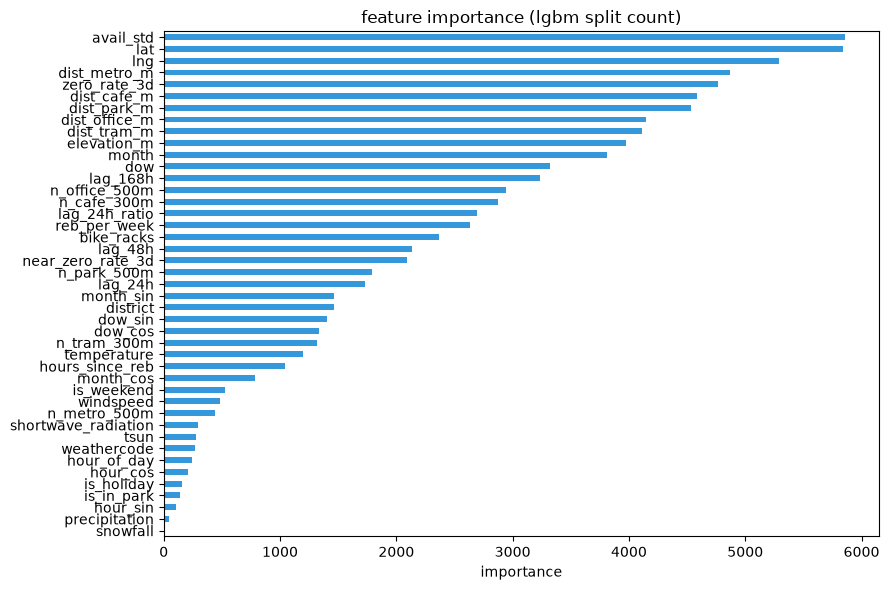

In [7]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('feature importance (lgbm split count)')
ax.set_xlabel('importance')
plt.tight_layout()
plt.show()

split count importance shows how many times each feature was used to make a split across all trees. it reflects which features the model found useful for grouping data, but it can be biased — features with more unique values tend to get more splits regardless of actual impact. the permutation importance section below gives a more reliable view.

## 4. model comparison

comparing lightgbm with different feature sets shows what each group of features actually adds. we also compare against xgboost, random forest, and a naive baseline.

the naive baseline predicts yesterday's same hour (lag_24h). this is the right comparison for a ≥24h-ahead model — a manager could simply say "expect the same as yesterday" without any ML. if the model cannot clearly beat this, there is no point in using it.

all tree models use geo and weather features. the four lightgbm rows isolate the contribution of each feature group.

In [8]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

WEATHER_COLS = ['temperature', 'precipitation', 'windspeed', 'weathercode', 'snowfall']
GEO_COLS_SET = set(GEO_COLS)

FEAT_CORE    = [c for c in FEATURE_COLS if c not in WEATHER_COLS and c not in GEO_COLS_SET]
FEAT_GEO     = [c for c in FEATURE_COLS if c not in WEATHER_COLS]
FEAT_WEATHER = [c for c in FEATURE_COLS if c not in GEO_COLS_SET]
FEAT_FULL    = FEATURE_COLS

results = []

baseline_pred = test['lag_24h'].fillna(test['lag_168h']).fillna(y_test.mean())
results.append({'model': 'naive (lag 24h)', 'features': 'none',
                'test_mae': mean_absolute_error(y_test, baseline_pred),
                'test_r2':  r2_score(y_test, baseline_pred)})

def quick_lgb(feats, n_trees):
    cat = ['station_uid'] if 'station_uid' in feats else 'auto'
    m = lgb.LGBMRegressor(objective='regression_l1',
                          n_estimators=n_trees, learning_rate=0.05, num_leaves=64,
                          min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                          force_col_wise=True, random_state=42, n_jobs=-1, verbose=-1)
    m.fit(X_train[feats], y_train, categorical_feature=cat)
    return m.predict(X_test[feats])

n = model.best_iteration_ if _use_early_stopping else _n_trees

for label, desc, feats in [
    ('lightgbm', 'time + lag',             FEAT_CORE),
    ('lightgbm', '+ geo',                  FEAT_GEO),
    ('lightgbm', '+ weather',              FEAT_WEATHER),
    ('lightgbm', '+ geo + weather (full)', FEAT_FULL),
]:
    pred = model.predict(X_test) if feats is FEAT_FULL else quick_lgb(feats, n)
    results.append({'model': label, 'features': desc,
                    'test_mae': mean_absolute_error(y_test, pred),
                    'test_r2':  r2_score(y_test, pred)})

# sample the training set for slow models — 300k rows is enough for a fair comparison
_sample_idx = np.random.default_rng(42).choice(len(X_train), size=min(300_000, len(X_train)), replace=False)
X_tr_s = X_train.iloc[_sample_idx]
y_tr_s = y_train.values[_sample_idx]
print(f'comparison models (xgboost, rf) trained on {len(X_tr_s):,} row sample')

xgb = XGBRegressor(n_estimators=n, learning_rate=0.05, max_depth=6,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_tr_s, y_tr_s)
pred_xgb = xgb.predict(X_test)
results.append({'model': 'xgboost', 'features': '+ geo + weather (sample)',
                'test_mae': mean_absolute_error(y_test, pred_xgb),
                'test_r2':  r2_score(y_test, pred_xgb)})

rf = RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=20,
                           n_jobs=-1, random_state=42)
rf.fit(X_tr_s, y_tr_s)
pred_rf = rf.predict(X_test)
results.append({'model': 'random forest', 'features': '+ geo + weather (sample)',
                'test_mae': mean_absolute_error(y_test, pred_rf),
                'test_r2':  r2_score(y_test, pred_rf)})

comparison = pd.DataFrame(results)
comparison[['test_mae', 'test_r2']] = comparison[['test_mae', 'test_r2']].round(3)
display(comparison)

comparison models (xgboost, rf) trained on 300,000 row sample


,model,features,test_mae,test_r2
0,naive (lag 24h),none,1.009,0.359
1,lightgbm,time + lag,0.896,0.566
2,lightgbm,+ geo,0.893,0.573
3,lightgbm,+ weather,0.897,0.567
4,lightgbm,+ geo + weather (full),0.893,0.580
5,xgboost,+ geo + weather (sample),0.973,0.578
6,random forest,+ geo + weather (sample),0.973,0.581


without lag_1h the model can no longer rely on current station state, so geo and weather features take on more weight. the comparison table shows how much each layer adds: time + lag features alone give a reasonable baseline, and geo (location, proximity to transit, POI density) and weather each add further improvement. this is the expected pattern for a multi-hour forecast — at a 24h+ horizon the lag features are weaker predictors, so the structural station properties and weather conditions carry more of the signal.

the naive baseline (lag_24h) predicts yesterday's same-hour value. this is a strong baseline precisely because bike demand is highly repeatable day-to-day. if the model only narrowly beats it, using the ml model is hard to justify. a clear margin shows the model is learning something beyond simple day-to-day repetition — specifically the interaction between time of day, station location, and weather that varies across days.

mae is in the same unit as the target (bikes). an mae of ~0.9 means on average the prediction is off by about 1 bike at a given station-hour. the model beats the naive baseline (mae 1.009) by about 11%, which is a meaningful improvement for rebalancing decisions at a 24h+ horizon.

## 5. evaluation

three graphs below show different aspects of model quality:

- **actual vs predicted**: each dot is one test observation. a perfect model would put all dots on the red diagonal line. the closer the scatter is to the diagonal, the better.
- **prediction bias by hour**: mean(predicted - actual) per hour of day. positive means the model overpredicts at that hour, negative means it underpredicts. some bias at peak hours is expected — demand spikes are harder to capture precisely.
- **mean residual heatmap**: same idea split by day of week and hour. mostly white means near-zero residuals — the model has no strong systematic blind spots.

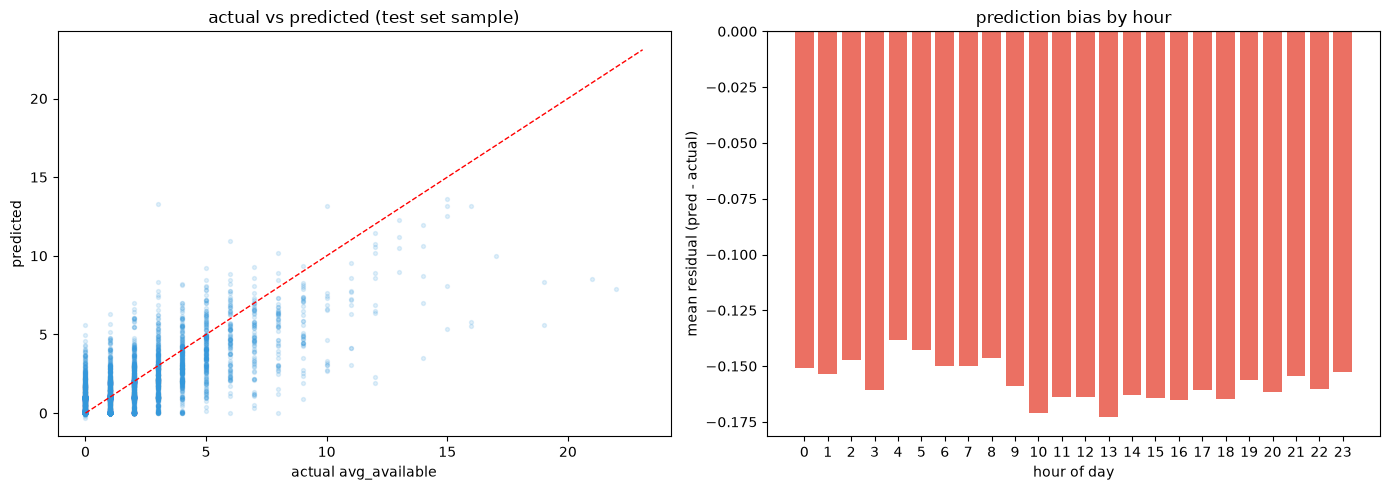

In [9]:
test = test.copy()
test['pred']     = model.predict(X_test)
test['residual'] = test['pred'] - test[TARGET]

# actual vs predicted
sample = test.sample(min(5000, len(test)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample[TARGET], sample['pred'], alpha=0.15, s=8, color='#3498db')
lim = max(sample[TARGET].max(), sample['pred'].max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[0].set_xlabel('actual avg_available')
axes[0].set_ylabel('predicted')
axes[0].set_title('actual vs predicted (test set sample)')

# mean bias by hour of day
res_hour = test.groupby('hour_of_day')['residual'].mean().reset_index()
axes[1].bar(res_hour['hour_of_day'], res_hour['residual'], color='#e74c3c', alpha=0.8)
axes[1].axhline(0, color='k', linewidth=0.8)
axes[1].set_xlabel('hour of day')
axes[1].set_ylabel('mean residual (pred - actual)')
axes[1].set_title('prediction bias by hour')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [10]:
# bootstrap 95% confidence interval for test MAE
# resamples the test set 1000 times to estimate how stable the metric is
rng = np.random.default_rng(42)
boot_mae = [
    mean_absolute_error(y_test.values[idx], test['pred'].values[idx])
    for idx in (rng.choice(len(y_test), size=len(y_test)) for _ in range(1000))
]
ci_lo, ci_hi = np.percentile(boot_mae, [2.5, 97.5])

mae_test  = mean_absolute_error(y_test, test['pred'])
rmse_test = mean_squared_error(y_test, test['pred']) ** 0.5
r2_test   = r2_score(y_test, test['pred'])

print(f'test MAE:   {mae_test:.4f}   95% CI: ({ci_lo:.4f}, {ci_hi:.4f})')
print(f'test RMSE:  {rmse_test:.4f}')
print(f'test R²:    {r2_test:.4f}')
print()
print('MAE = average error in bikes. 0.12 means on average the prediction is off by 0.12 bikes.')
print('RMSE penalises large errors more — if RMSE >> MAE, some stations have occasional big spikes.')

test MAE:   0.8934   95% CI: (0.8902, 0.8968)
test RMSE:  1.4466
test R²:    0.5803

MAE = average error in bikes. 0.12 means on average the prediction is off by 0.12 bikes.
RMSE penalises large errors more — if RMSE >> MAE, some stations have occasional big spikes.


residual range: -0.231 to -0.101
colorbar cap: ±0.185  (90th pct of abs residuals; actual max 0.231)
note: these are mean residuals across all stations — individual station errors are much larger


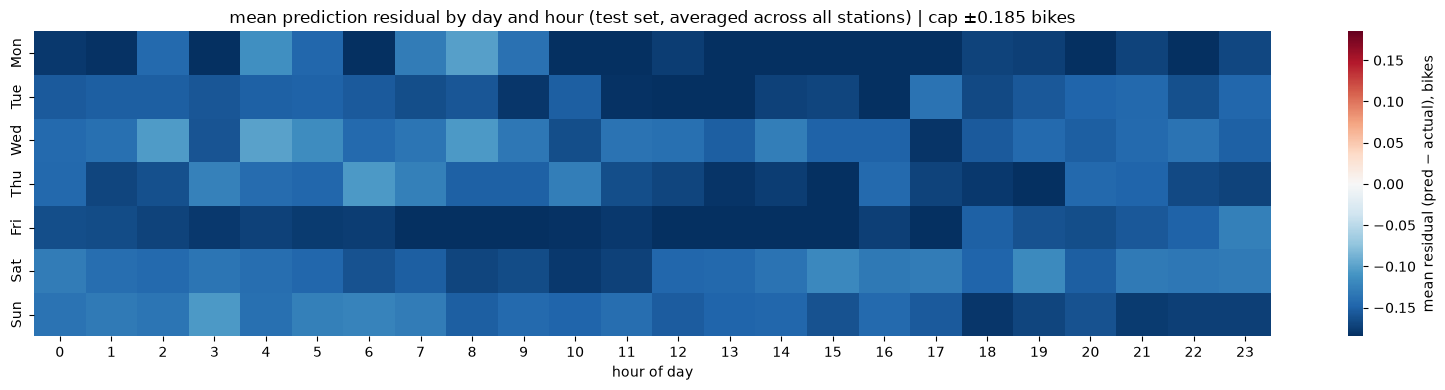


most overpredicted hour: {'dow': 2.0, 'hour_of_day': 4.0, 'residual': -0.10117206172909415}
most underpredicted hour: {'dow': 0.0, 'hour_of_day': 3.0, 'residual': -0.2307787692426015}


In [11]:
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

res_hm = test.groupby(['dow', 'hour_of_day'])['residual'].mean().reset_index()
res_pivot = res_hm.pivot(index='dow', columns='hour_of_day', values='residual')
res_pivot.index = [dow_labels[i] for i in res_pivot.index]

# cap at 90th percentile of absolute residuals so a few extreme cells don't wash out
# the rest of the palette — but don't force a floor, let the actual data set the scale.
# note: this heatmap shows AVERAGE residual across all 300+ stations. individual station
# biases (e.g. +1.4 at maroldovo, -2.2 at u pragovky) cancel each other out here,
# so the aggregate looks near-zero even when per-station errors are large.
cap = float(np.nanpercentile(np.abs(res_pivot.values), 90))
# only add a tiny floor so the colorbar doesn't collapse to a point if residuals are very small
cap = max(cap, 0.02)

actual_max = float(np.nanmax(np.abs(res_pivot.values)))
print(f'residual range: {np.nanmin(res_pivot.values):.3f} to {np.nanmax(res_pivot.values):.3f}')
print(f'colorbar cap: ±{cap:.3f}  (90th pct of abs residuals; actual max {actual_max:.3f})')
print('note: these are mean residuals across all stations — individual station errors are much larger')

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(res_pivot, ax=ax, cmap='RdBu_r', center=0, vmin=-cap, vmax=cap,
            cbar_kws={'label': 'mean residual (pred − actual), bikes'})
ax.set_title(
    f'mean prediction residual by day and hour (test set, averaged across all stations) | cap ±{cap:.3f} bikes'
)
ax.set_xlabel('hour of day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nmost overpredicted hour:', res_hm.loc[res_hm["residual"].idxmax(), ["dow","hour_of_day","residual"]].to_dict())
print('most underpredicted hour:', res_hm.loc[res_hm["residual"].idxmin(), ["dow","hour_of_day","residual"]].to_dict())

stations most overpredicted at night (0-5am):

,name,mean_residual,mean_actual,mean_pred,reb_per_week,n_obs
459,P13 - Třebonice (betonový plácek u plotu),0.622254,2.725806,3.348060,0.615,124
315,P8 - Libeňský ostrov,0.574273,2.588710,3.162982,1.038,124
228,P8 - roh Křižíkova/ Thámova,0.516810,3.468254,3.985064,1.846,126
268,P2 - Botičská / Na Děkance (stojan u kraje voz...,0.511035,2.285714,2.796749,0.154,77
699,P8 - Florenc - bus terminal,0.435998,1.919355,2.355353,0.269,124
74,P4-Dvorecké náměstí,0.435066,1.306452,1.741518,0.500,124
568,P7 - Nádraží Holešovice 3,0.359461,1.500000,1.859461,0.231,124
157,P5-Smíchovské nádraží (výstup E3),0.345982,1.959677,2.305659,0.077,124
173,P7 - Jankovcova 49 (vyhrazené stání),0.344108,3.395161,3.739269,0.423,124
56,P8-Matematicko - fyzikální fakulta Univerzity ...,0.339589,3.330645,3.670234,1.885,124



stations most underpredicted at night (0-5am):


,name,mean_residual,mean_actual,mean_pred,reb_per_week,n_obs
31,P12-Kino Modřany,-1.129073,9.274194,8.145120,0.923,124
569,P4 - Koleje Podolí,-1.149172,3.330645,2.181473,0.846,124
592,P4 - Nuselský pivovar,-1.269876,6.379032,5.109156,0.154,124
53,P3-Slavíkova - Kubelíkova,-1.673450,6.753968,5.080518,6.500,126
91,P6 - Hradčanská (výstup E6),-2.952425,6.661290,3.708865,5.115,124



night-hour detail for most overpredicted station: P13 - Třebonice (betonový plácek u plotu)
               hour  hour_of_day  avg_available     pred  residual  lag_24h  hours_since_reb
2026-07-27 00:00:00            0            2.0 1.873879 -0.126121      1.0              NaN
2026-07-27 01:00:00            1            2.0 1.873879 -0.126121      1.0              NaN
2026-07-27 03:00:00            3            2.0 1.874843 -0.125157      1.0              NaN
2026-07-28 00:00:00            0            2.0 2.721365  0.721365      2.0              NaN
2026-07-28 01:00:00            1            2.0 2.734299  0.734299      2.0              NaN
2026-07-28 03:00:00            3            2.0 2.750441  0.750441      2.0              NaN
2026-07-29 00:00:00            0            2.0 3.001296  1.001296      2.0              NaN
2026-07-29 01:00:00            1            2.0 3.001296  1.001296      2.0              NaN
2026-07-29 03:00:00            3            2.0 3.014230  1.014230    

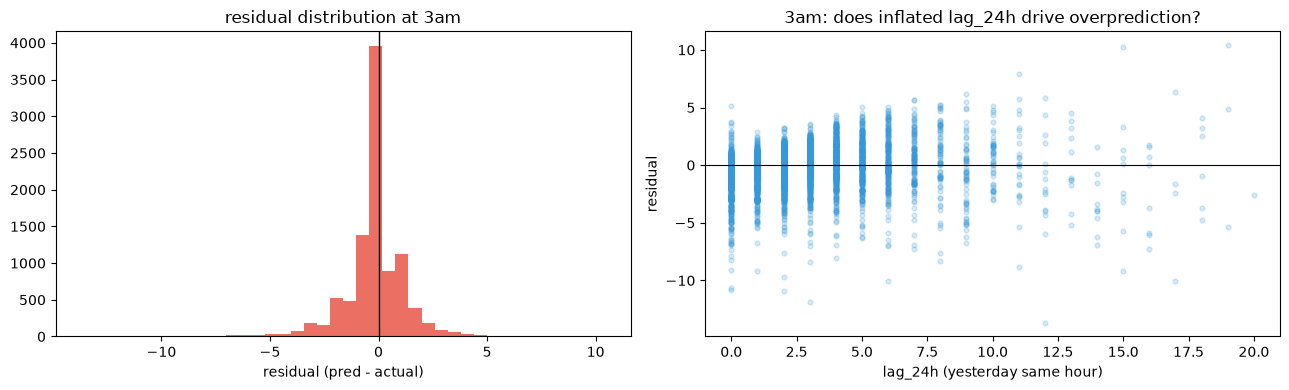


3am: mean residual=-0.161  n_obs=9,725  pct overpredicted=53.9%


In [12]:
# investigate problematic hours: which stations drive the 3am overprediction?
# overprediction (positive residual) means model expected more bikes than were there.
# most likely cause: lag_24h was inflated by a prior-night delivery, model trusted it.

NIGHT_HOURS = [0, 1, 2, 3, 4, 5]

night_test = test[test['hour_of_day'].isin(NIGHT_HOURS)].copy()

agg_dict = {
    'mean_residual': ('residual', 'mean'),
    'n_obs':         ('residual', 'count'),
    'mean_actual':   ('avg_available', 'mean'),
    'mean_pred':     ('pred', 'mean'),
}
if 'reb_per_week' in night_test.columns:
    agg_dict['reb_per_week'] = ('reb_per_week', 'first')

station_night = (
    night_test.groupby('station_uid')
    .agg(**agg_dict)
    .reset_index()
    .merge(station_names, on='station_uid', how='left')
    .sort_values('mean_residual', ascending=False)
)

cols_show = ['name', 'mean_residual', 'mean_actual', 'mean_pred', 'reb_per_week', 'n_obs']
cols_show = [c for c in cols_show if c in station_night.columns]

print('stations most overpredicted at night (0-5am):')
display(station_night[cols_show].head(15))
print('\nstations most underpredicted at night (0-5am):')
display(station_night[cols_show].tail(5))

# raw data for the worst station: confirms the pattern
worst_uid  = station_night.iloc[0]['station_uid']
worst_name = station_night.iloc[0].get('name', str(worst_uid))
worst_night = night_test[night_test['station_uid'] == worst_uid].sort_values('hour')
print(f'\nnight-hour detail for most overpredicted station: {worst_name}')
print(worst_night[['hour', 'hour_of_day', 'avg_available', 'pred', 'residual',
                    'lag_24h', 'hours_since_reb']].to_string(index=False))

# scatter: does high lag_24h cause the 3am overprediction?
hour3 = test[test['hour_of_day'] == 3]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(hour3['residual'], bins=40, color='#e74c3c', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='k', linewidth=1)
axes[0].set_xlabel('residual (pred - actual)')
axes[0].set_title('residual distribution at 3am')

axes[1].scatter(hour3['lag_24h'], hour3['residual'], alpha=0.2, s=12, color='#3498db')
axes[1].axhline(0, color='k', linewidth=0.8)
axes[1].set_xlabel('lag_24h (yesterday same hour)')
axes[1].set_ylabel('residual')
axes[1].set_title('3am: does inflated lag_24h drive overprediction?')

plt.tight_layout()
plt.show()

print(f'\n3am: mean residual={hour3["residual"].mean():.3f}  '
      f'n_obs={len(hour3):,}  '
      f'pct overpredicted={(hour3["residual"] > 0).mean()*100:.1f}%')

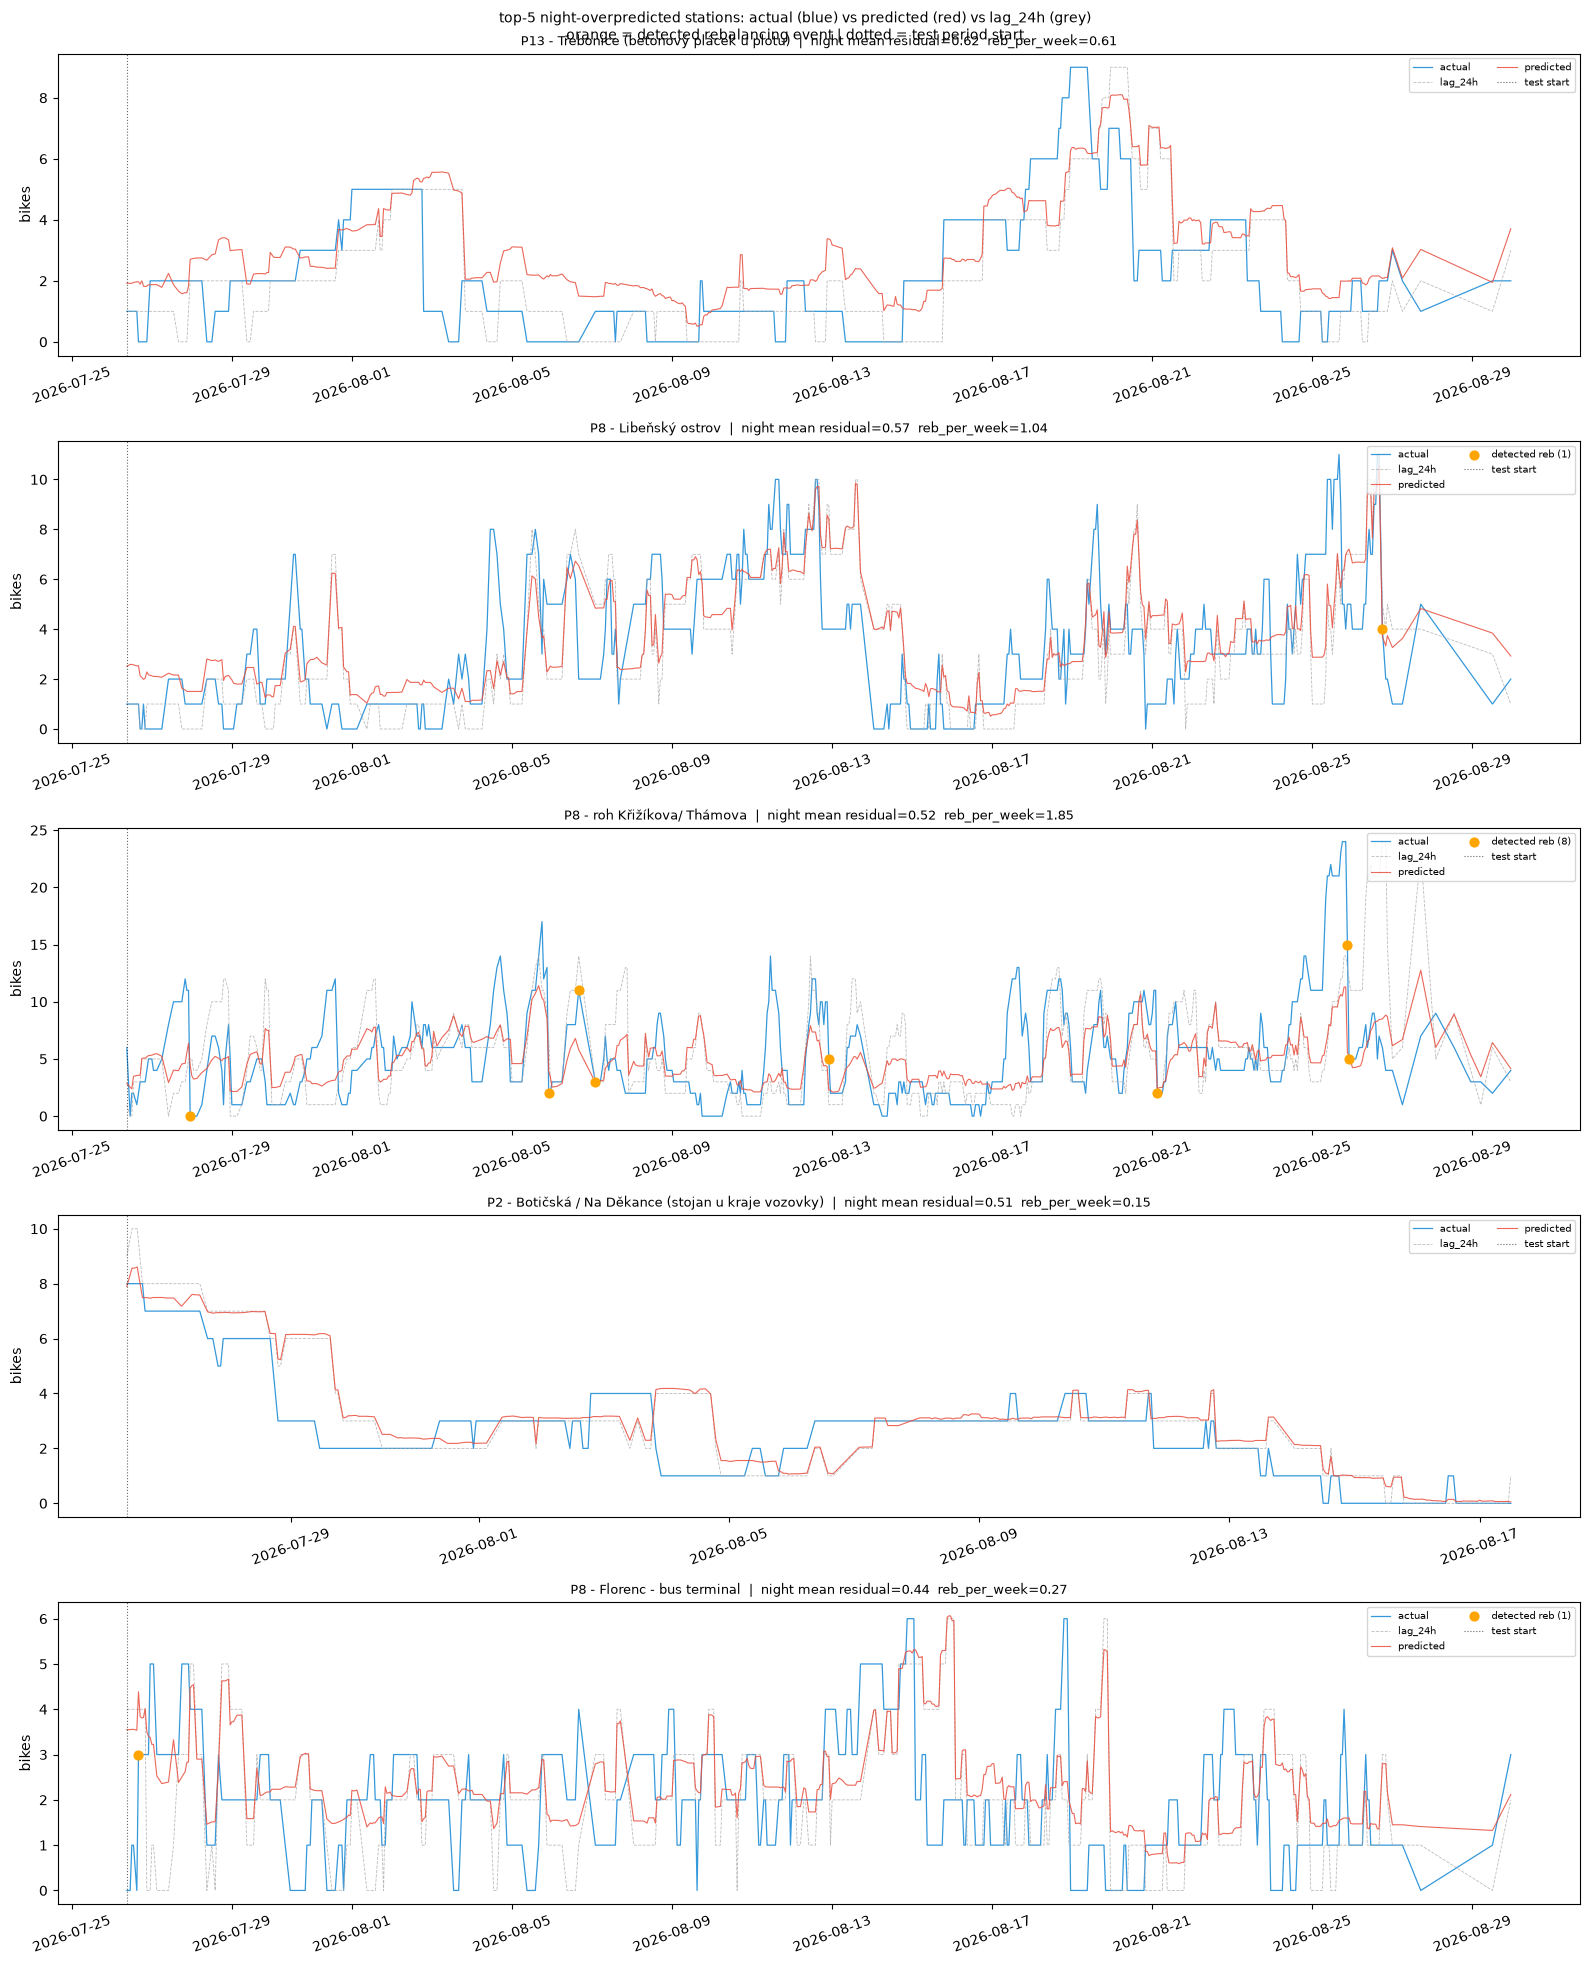

In [13]:
# time series for top-5 night-overpredicted stations.
# shows actual vs predicted vs lag_24h to see the exact moment bikes appeared
# and whether our detector caught it (orange dot = detected delivery).
# dotted vertical line = start of test period.

TOP_N = 5
worst_night_uids = station_night.head(TOP_N)['station_uid'].tolist()

# include a few days before test start so we can see the spike that seeded the inflated lag
focus_start = test['hour'].min() - pd.Timedelta(days=5)

fig, axes = plt.subplots(TOP_N, 1, figsize=(16, 4 * TOP_N), sharex=False)

for ax, uid in zip(axes, worst_night_uids):
    name_row = station_names[station_names['station_uid'] == uid]
    name = name_row['name'].values[0] if len(name_row) else str(uid)
    night_row = station_night[station_night['station_uid'] == uid].iloc[0]

    series = df[(df['station_uid'] == uid) & (df['hour'] >= focus_start)].sort_values('hour')
    test_s  = test[test['station_uid'] == uid].sort_values('hour')

    ax.plot(series['hour'], series['avg_available'],
            color='#3498db', linewidth=0.9, label='actual')
    ax.plot(series['hour'], series['lag_24h'].clip(lower=0),
            color='#aaaaaa', linewidth=0.6, linestyle='--', alpha=0.8, label='lag_24h')
    if len(test_s):
        ax.plot(test_s['hour'], test_s['pred'],
                color='#e74c3c', linewidth=0.8, alpha=0.85, label='predicted')

    # orange dots = hours where a rebalancing event was detected (hours_since_reb == 0)
    reb_pts = series[series['hours_since_reb'] == 0]
    if len(reb_pts):
        ax.scatter(reb_pts['hour'], reb_pts['avg_available'],
                   color='orange', s=40, zorder=5, label=f'detected reb ({len(reb_pts)})')

    ax.axvline(test['hour'].min(), color='k', linewidth=0.8, linestyle=':', alpha=0.6,
               label='test start')
    ax.set_title(
        f'{name}  |  night mean residual={night_row["mean_residual"]:.2f}  '
        f'reb_per_week={night_row.get("reb_per_week", "n/a"):.2f}',
        fontsize=9
    )
    ax.set_ylabel('bikes')
    ax.legend(loc='upper right', fontsize=7, ncol=2)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('top-5 night-overpredicted stations: actual (blue) vs predicted (red) vs lag_24h (grey)\n'
             'orange = detected rebalancing event | dotted = test period start', fontsize=10)
plt.tight_layout()
plt.show()

median station MAE:  0.784
mean station MAE:    0.893

worst 10 stations:


,name,mae,rmse,n
685,P7 - Maroldovo panoráma,4.062172,5.047442,584.0
91,P6 - Hradčanská (výstup E6),3.411271,5.220360,578.0
208,P5-zastávka Lihovar,3.304338,4.265913,584.0
54,P4 - Raiffeisen Bank,3.033143,4.495233,584.0
490,P9 - U Pragovky,2.744236,3.301698,584.0
228,P8 - roh Křižíkova/ Thámova,2.644686,3.626172,591.0
73,P8-Elsnicovo náměstí,2.595608,3.432228,584.0
314,P7 - Vltavská (výstup E6),2.586564,3.431237,584.0
557,P2 - Vnislavova / Rašínovo nábřeží,2.578201,3.262285,584.0
104,P2 - Výtoň u železničního mostu,2.496171,3.408765,584.0


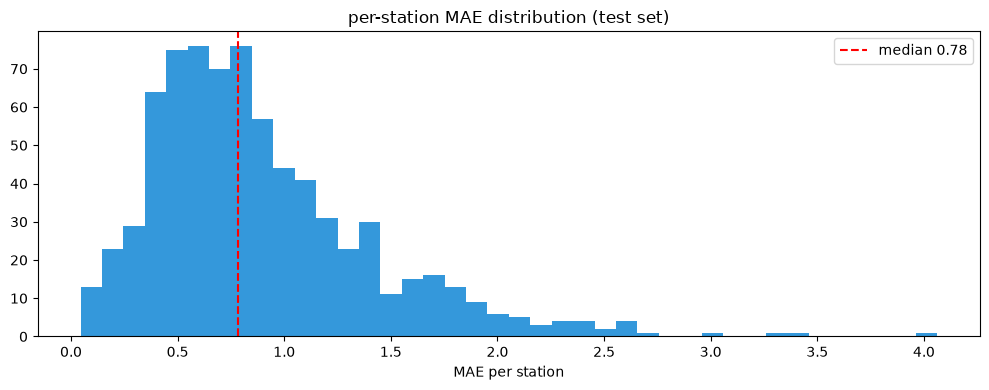

In [14]:
per_station = (
    test.groupby('station_uid')
    .apply(lambda g: pd.Series({
        'mae':  mean_absolute_error(g[TARGET], g['pred']),
        'rmse': mean_squared_error(g[TARGET], g['pred']) ** 0.5,
        'n':    len(g),
    }))
    .reset_index()
    .merge(station_names, on='station_uid', how='left')
    .sort_values('mae', ascending=False)
)

print(f'median station MAE:  {per_station["mae"].median():.3f}')
print(f'mean station MAE:    {per_station["mae"].mean():.3f}')
print(f'\nworst 10 stations:')
display(per_station[['name', 'mae', 'rmse', 'n']].head(10))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(per_station['mae'], bins=40, color='#3498db', edgecolor='none')
ax.axvline(per_station['mae'].median(), color='r', linestyle='--',
           label=f'median {per_station["mae"].median():.2f}')
ax.set_xlabel('MAE per station')
ax.set_title('per-station MAE distribution (test set)')
ax.legend()
plt.tight_layout()
plt.show()

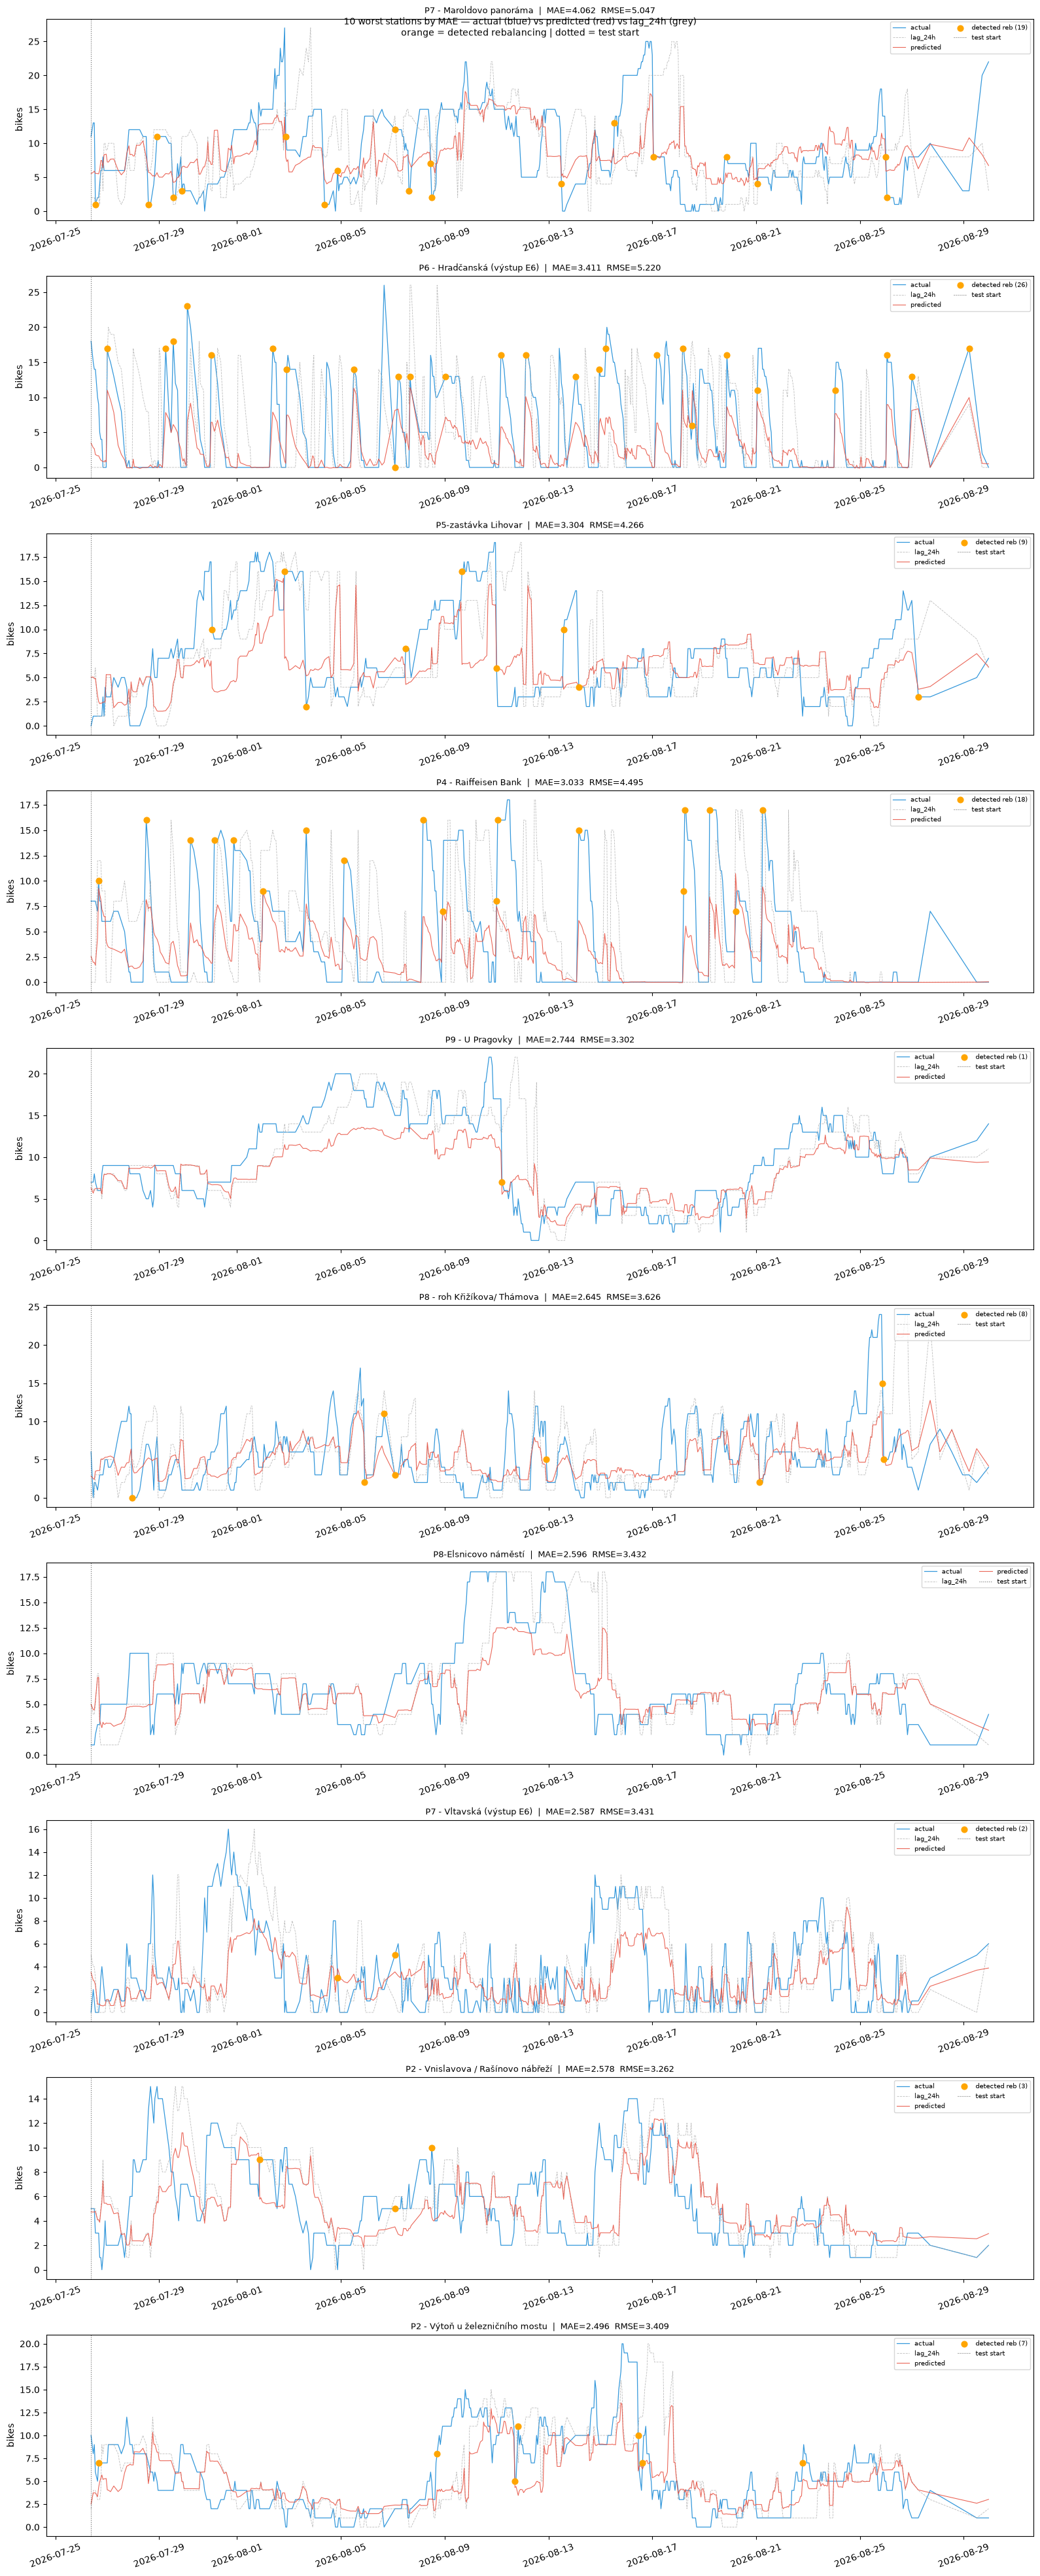

In [15]:
# time series for the 10 worst-mae stations.
# same layout as the night investigation: actual, lag_24h, predicted, detected rebalancing.
# shows the full test window (+ 5 days before) to see what pattern drives the high error.

WORST_N = 10
worst_uids = per_station.head(WORST_N)['station_uid'].tolist()

focus_start = test['hour'].min() - pd.Timedelta(days=5)

fig, axes = plt.subplots(WORST_N, 1, figsize=(16, 4 * WORST_N), sharex=False)

for ax, uid in zip(axes, worst_uids):
    name_row = station_names[station_names['station_uid'] == uid]
    name = name_row['name'].values[0] if len(name_row) else str(uid)
    ps_row = per_station[per_station['station_uid'] == uid].iloc[0]

    series  = df[(df['station_uid'] == uid) & (df['hour'] >= focus_start)].sort_values('hour')
    test_s  = test[test['station_uid'] == uid].sort_values('hour')

    ax.plot(series['hour'], series['avg_available'],
            color='#3498db', linewidth=0.9, label='actual')
    ax.plot(series['hour'], series['lag_24h'].clip(lower=0),
            color='#aaaaaa', linewidth=0.6, linestyle='--', alpha=0.8, label='lag_24h')
    if len(test_s):
        ax.plot(test_s['hour'], test_s['pred'],
                color='#e74c3c', linewidth=0.8, alpha=0.85, label='predicted')

    reb_pts = series[series['hours_since_reb'] == 0]
    if len(reb_pts):
        ax.scatter(reb_pts['hour'], reb_pts['avg_available'],
                   color='orange', s=40, zorder=5, label=f'detected reb ({len(reb_pts)})')

    ax.axvline(test['hour'].min(), color='k', linewidth=0.8, linestyle=':', alpha=0.6,
               label='test start')
    ax.set_title(
        f'{name}  |  MAE={ps_row["mae"]:.3f}  RMSE={ps_row["rmse"]:.3f}',
        fontsize=9
    )
    ax.set_ylabel('bikes')
    ax.legend(loc='upper right', fontsize=7, ncol=2)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('10 worst stations by MAE — actual (blue) vs predicted (red) vs lag_24h (grey)\n'
             'orange = detected rebalancing | dotted = test start', fontsize=10)
plt.tight_layout()
plt.show()

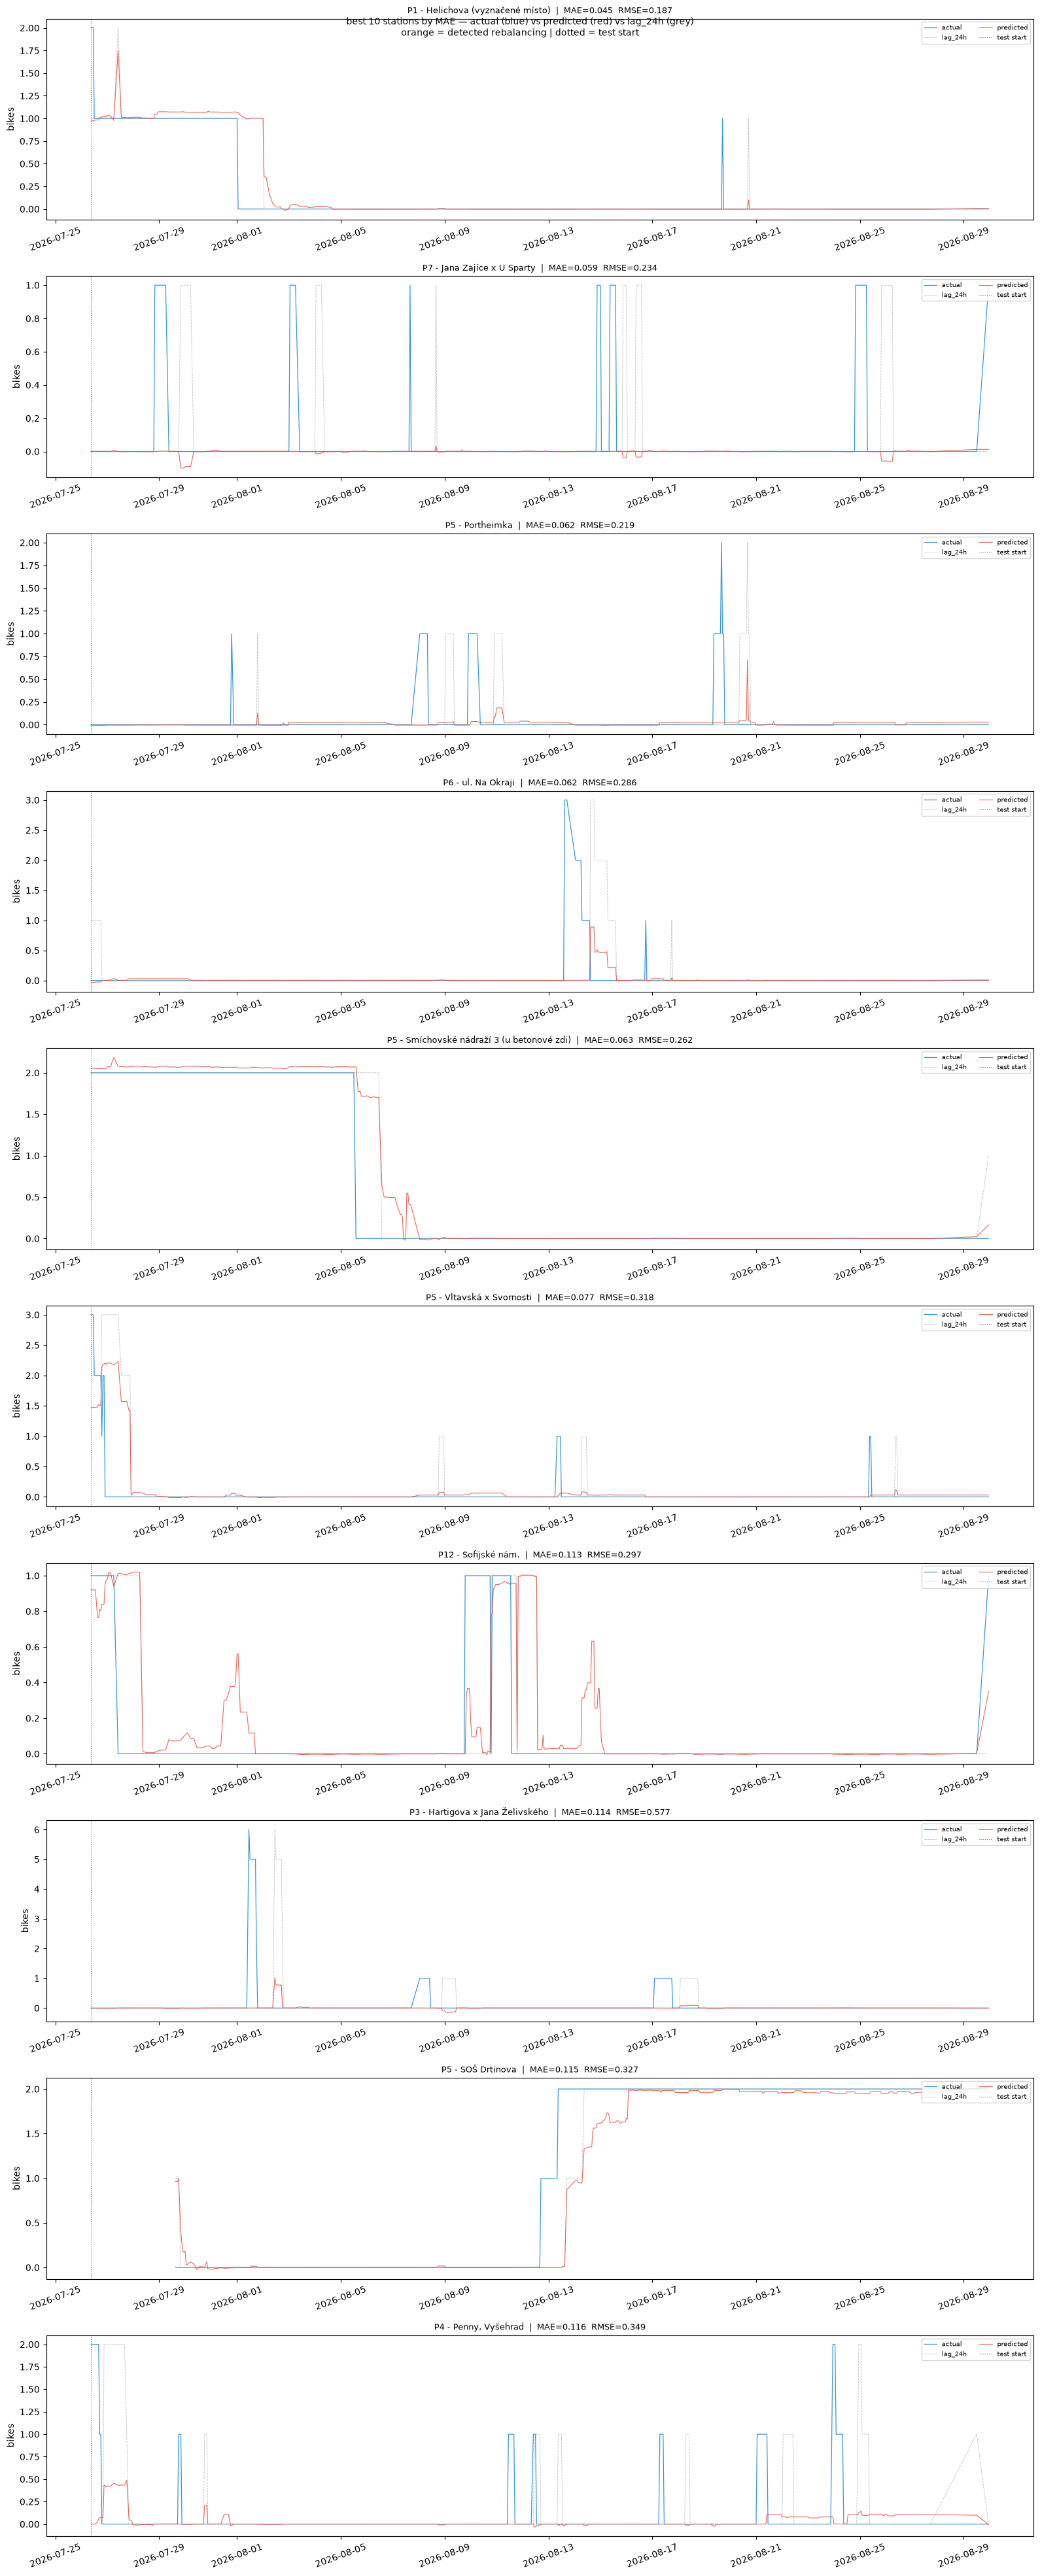

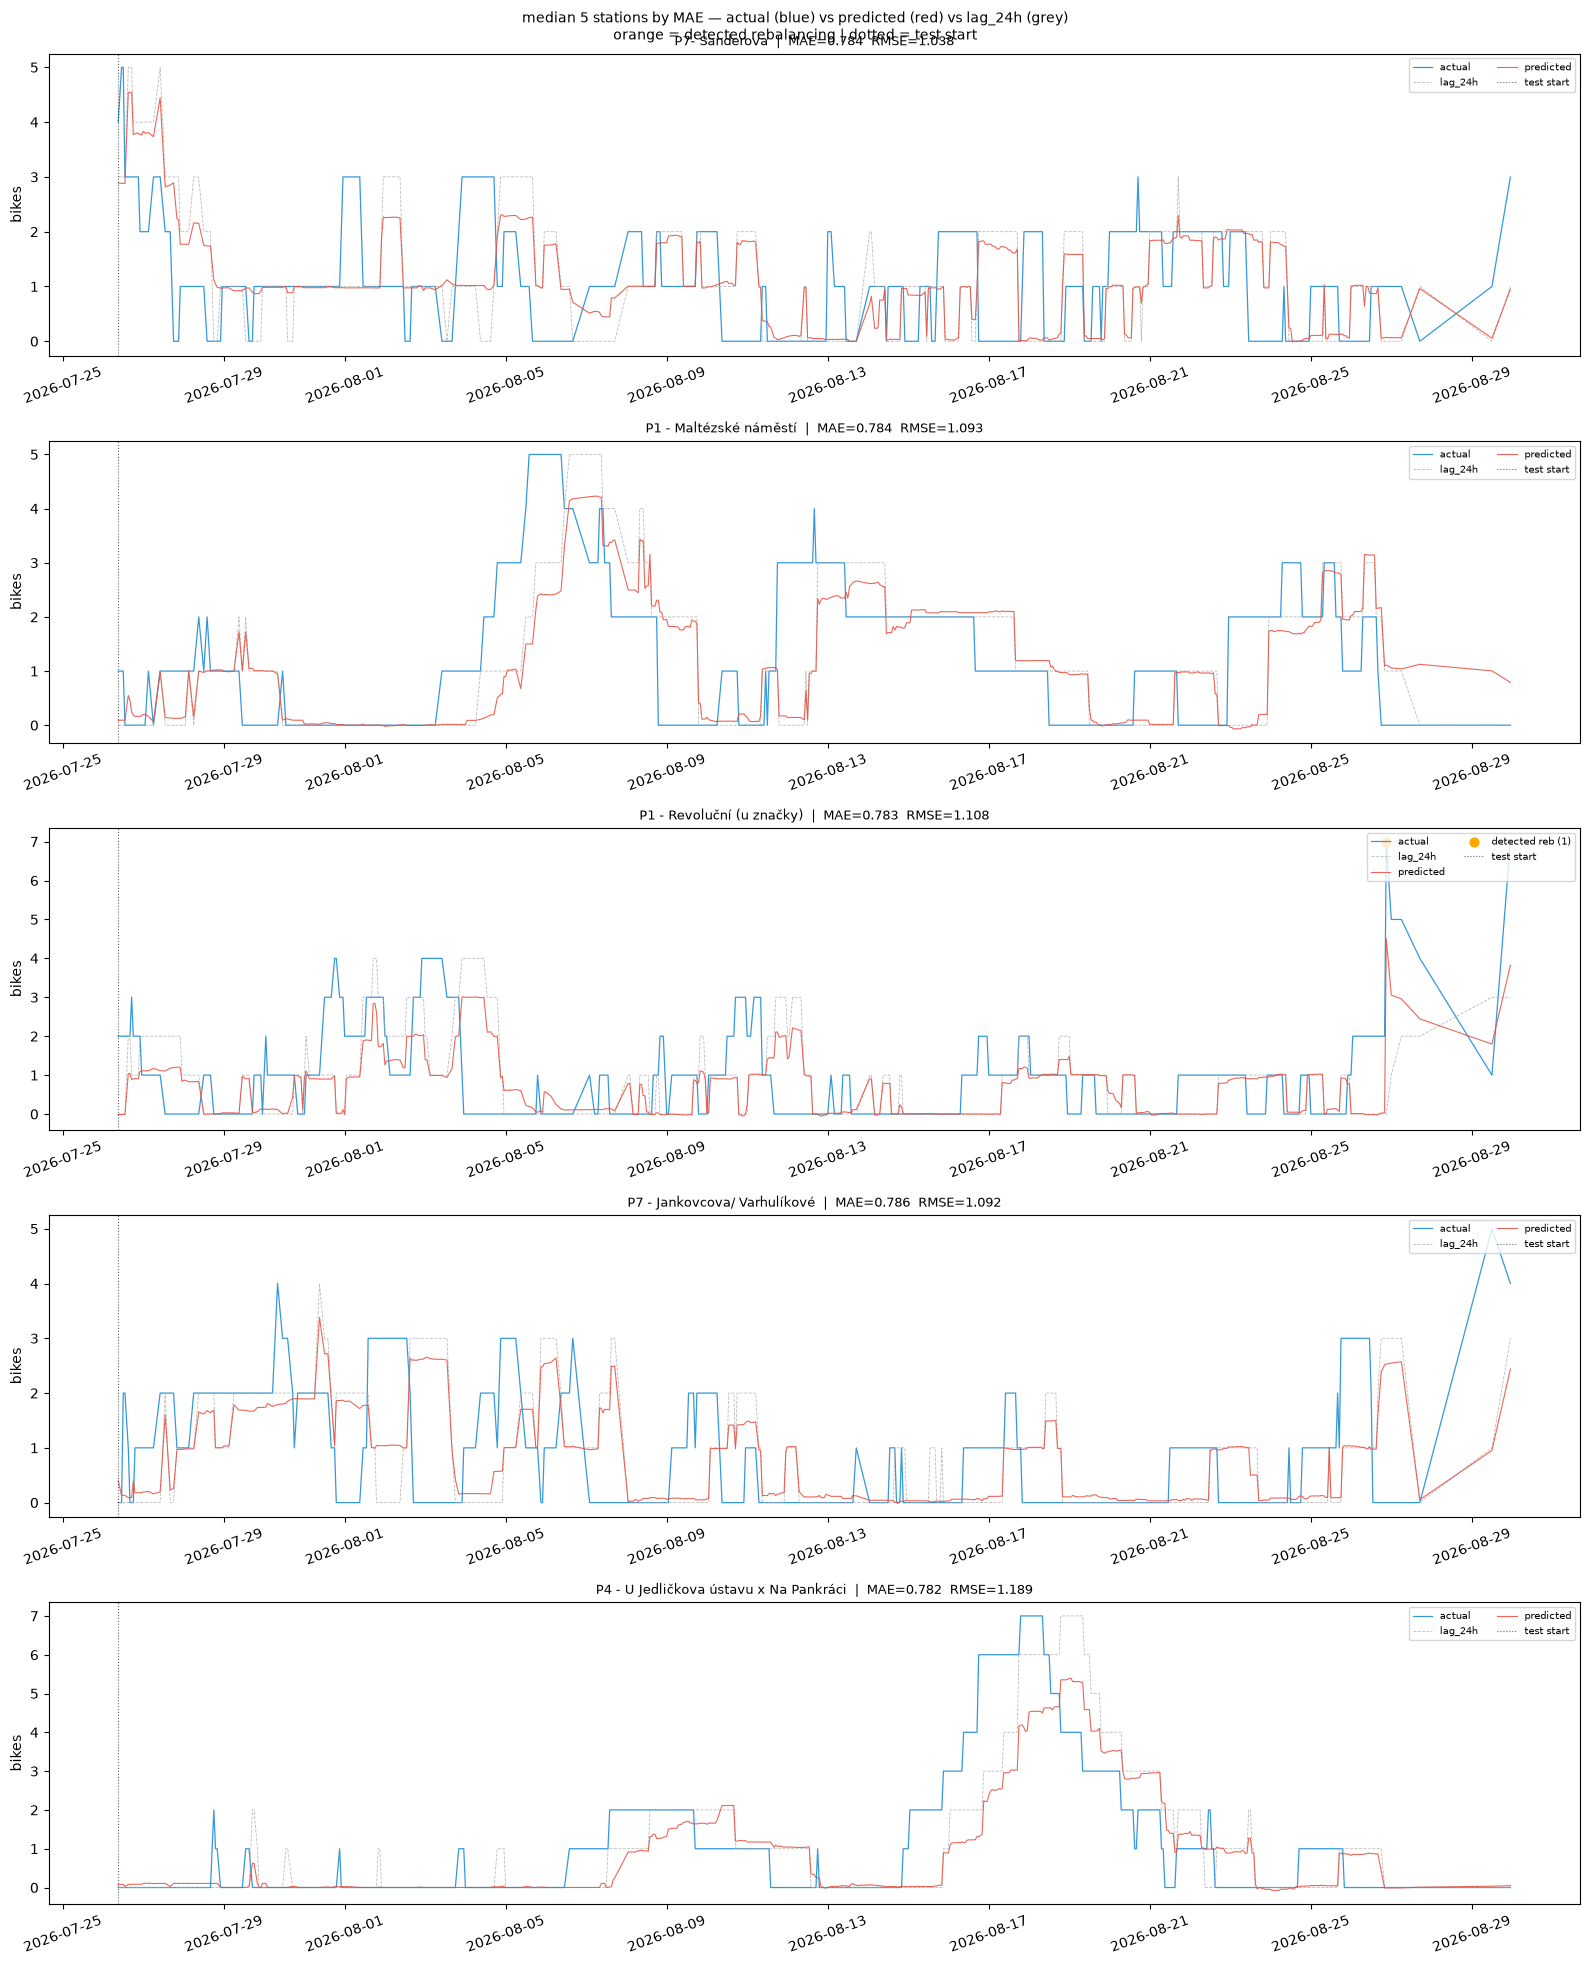

In [16]:
# best predicted stations + stations near median mae.
# the worst-station graphs show where the model struggles;
# these show what "good prediction" looks like and whether the median station is boring or interesting.

BEST_N   = 10
MEDIAN_N = 5

best_uids = per_station.tail(BEST_N)['station_uid'].tolist()[::-1]  # tail = lowest mae (sorted desc)

median_mae = per_station['mae'].median()
per_station['_dist_median'] = (per_station['mae'] - median_mae).abs()
median_uids = per_station.nsmallest(MEDIAN_N, '_dist_median')['station_uid'].tolist()

focus_start = test['hour'].min() - pd.Timedelta(days=5)

for group_label, uid_list, n in [('best', best_uids, BEST_N), ('median', median_uids, MEDIAN_N)]:
    fig, axes = plt.subplots(n, 1, figsize=(16, 4 * n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, uid in zip(axes, uid_list):
        name_row = station_names[station_names['station_uid'] == uid]
        name = name_row['name'].values[0] if len(name_row) else str(uid)
        ps_row = per_station[per_station['station_uid'] == uid].iloc[0]

        series = df[(df['station_uid'] == uid) & (df['hour'] >= focus_start)].sort_values('hour')
        test_s = test[test['station_uid'] == uid].sort_values('hour')

        ax.plot(series['hour'], series['avg_available'],
                color='#3498db', linewidth=0.9, label='actual')
        ax.plot(series['hour'], series['lag_24h'].clip(lower=0),
                color='#aaaaaa', linewidth=0.6, linestyle='--', alpha=0.8, label='lag_24h')
        if len(test_s):
            ax.plot(test_s['hour'], test_s['pred'],
                    color='#e74c3c', linewidth=0.8, alpha=0.85, label='predicted')

        reb_pts = series[series['hours_since_reb'] == 0]
        if len(reb_pts):
            ax.scatter(reb_pts['hour'], reb_pts['avg_available'],
                       color='orange', s=40, zorder=5, label=f'detected reb ({len(reb_pts)})')

        ax.axvline(test['hour'].min(), color='k', linewidth=0.8, linestyle=':', alpha=0.6,
                   label='test start')
        ax.set_title(
            f'{name}  |  MAE={ps_row["mae"]:.3f}  RMSE={ps_row["rmse"]:.3f}',
            fontsize=9,
        )
        ax.set_ylabel('bikes')
        ax.legend(loc='upper right', fontsize=7, ncol=2)
        ax.tick_params(axis='x', rotation=20)

    plt.suptitle(
        f'{group_label} {n} stations by MAE — actual (blue) vs predicted (red) vs lag_24h (grey)\n'
        f'orange = detected rebalancing | dotted = test start',
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

per_station.drop(columns=['_dist_median'], inplace=True)

## 6. per-station analysis

the overall mae hides a lot of variation. most stations are predicted well but a small number of stations are much harder to predict — typically high-traffic hubs with irregular rebalancing activity.

the histogram shows how mae is distributed across all stations. the table shows the 10 worst-predicted stations. n = number of test observations for that station (stations with few observations may have less reliable mae estimates).

rmse penalises large errors more than mae (because errors are squared before averaging). if rmse is much higher than mae for a station, it means occasional large spikes rather than consistent small errors.

## 5. permutation importance

permutation importance asks: "if i randomly shuffle the values of one feature and re-run predictions, how much does MAE increase?" a big increase means the model relied heavily on that feature. this is more reliable than split-count importance because it measures actual impact on the metric, not just how often the feature was used to build a tree node.

features with higher increase in mae are more important. the error bars show variance across the 5 repetitions — a feature with small error bars has a stable effect. features with near-zero impact can be safely removed without affecting model quality.

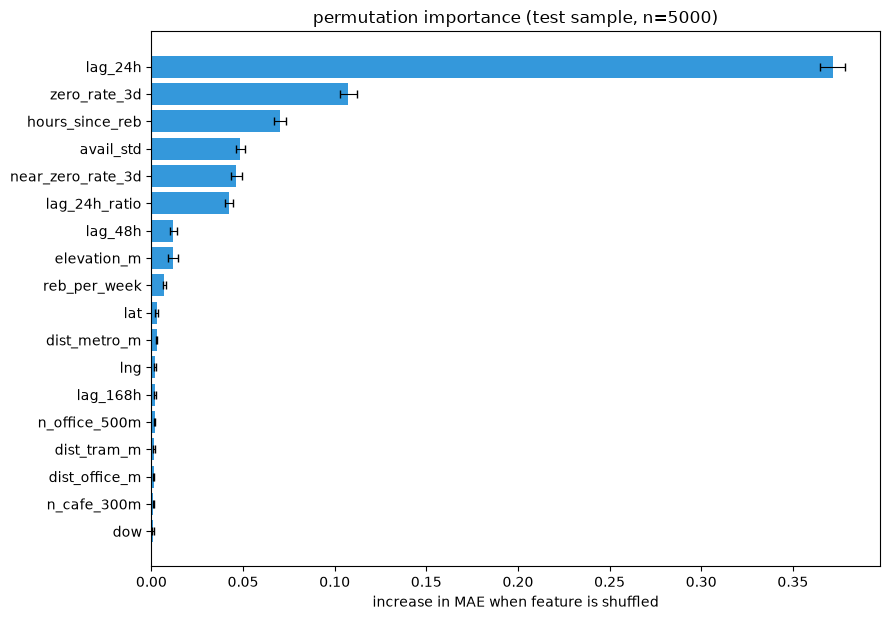

In [17]:
from sklearn.inspection import permutation_importance as sk_pi

# use 5000 test rows for speed — full test set would take many minutes
pi_idx = np.random.default_rng(42).choice(len(X_test), size=min(5000, len(X_test)), replace=False)
X_pi   = X_test.iloc[pi_idx]
y_pi   = y_test.values[pi_idx]

pi_result = sk_pi(
    model, X_pi, y_pi,
    scoring='neg_mean_absolute_error',
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

pi_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': pi_result.importances_mean,
    'std':        pi_result.importances_std,
}).sort_values('importance', ascending=True)

# only show features with non-trivial importance
top_pi = pi_df[pi_df['importance'] > 0.001]

fig, ax = plt.subplots(figsize=(9, max(4, len(top_pi) * 0.35)))
ax.barh(top_pi['feature'], top_pi['importance'], xerr=top_pi['std'],
        color='#3498db', capsize=3, error_kw={'linewidth': 0.8})
ax.set_xlabel('increase in MAE when feature is shuffled')
ax.set_title('permutation importance (test sample, n=5000)')
plt.tight_layout()
plt.show()

## 7. save model

save the trained model and the list of feature columns. the api loads both at startup — the feature list tells it which columns to build and in what order before passing data to the model.

In [18]:
out_path = pathlib.Path('../data/model.lgb')
out_path.parent.mkdir(exist_ok=True)
model.booster_.save_model(str(out_path))
print(f'saved to {out_path}  ({out_path.stat().st_size / 1e3:.0f} KB)')

import json
(out_path.parent / 'feature_cols.json').write_text(json.dumps(FEATURE_COLS))
print(f'feature list saved to {out_path.parent / "feature_cols.json"}')

saved to ..\data\model.lgb  (8866 KB)
feature list saved to ..\data\feature_cols.json
